In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")

# 1. Carga del Dataset
df = pd.read_csv('cupid_algorithm_dataset.csv')
df.head(20)

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68
5,6,40,3,Urban,Science,0.75,0.45,0.40,0.71,0.54,...,0.12,0.36,0.04,0.14,1.00,Receiving Gifts,0.83,67.2,1,64
6,7,28,1,Suburban,Tech,0.36,0.47,0.84,0.56,0.49,...,0.26,0.26,0.49,0.36,0.43,Acts of Service,0.43,66.0,1,119
7,8,28,1,Suburban,Engineering,0.00,0.28,0.33,0.95,0.76,...,0.73,0.40,0.42,0.62,0.71,Acts of Service,0.75,43.8,0,60
8,9,41,4,Urban,Entrepreneurship,0.52,0.69,0.50,0.25,0.34,...,0.58,0.32,0.50,0.51,0.60,Words of Affirmation,0.86,72.9,1,69
9,10,53,5,Rural,Law,0.75,0.65,0.61,0.49,0.28,...,0.61,0.43,0.63,0.37,0.95,Physical Touch,0.32,60.9,0,85


In [31]:
# 2. Información Básica y Calidad de los Datos
print("--- Forma del Dataset ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n--- Tipos de Datos e Información General ---")
print(df.info())

print("\n--- Valores Nulos ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Solo muestra si hay nulos

print("\n--- Estadísticas Descriptivas ---")
display(df.describe()) # Si usas script normal, cambia 'display' por 'print'

--- Forma del Dataset ---
Filas: 100000, Columnas: 30

--- Tipos de Datos e Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float

,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.558140,2.951980,0.496463,0.499959,0.500131,0.501397,0.498643,0.499697,0.500012,...,0.499897,0.499177,0.500100,0.500063,0.500779,0.500324,0.500310,63.122273,0.428810,68.906250
std,28867.657797,10.951788,1.117733,0.174898,0.223607,0.224783,0.223860,0.223444,0.224779,0.226265,...,0.223567,0.223989,0.223253,0.223312,0.224214,0.226398,0.225954,10.705780,0.494909,21.334574
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.500000,0.000000,0.000000
25%,25000.750000,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.320000,0.330000,0.330000,...,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,55.900000,0.000000,54.000000
50%,50000.500000,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,63.000000,0.000000,69.000000
75%,75000.250000,46.000000,4.000000,0.620000,0.670000,0.670000,0.680000,0.670000,0.670000,0.670000,...,0.670000,0.670000,0.670000,0.670000,0.680000,0.680000,0.670000,70.300000,1.000000,83.000000
max,100000.000000,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,120.000000


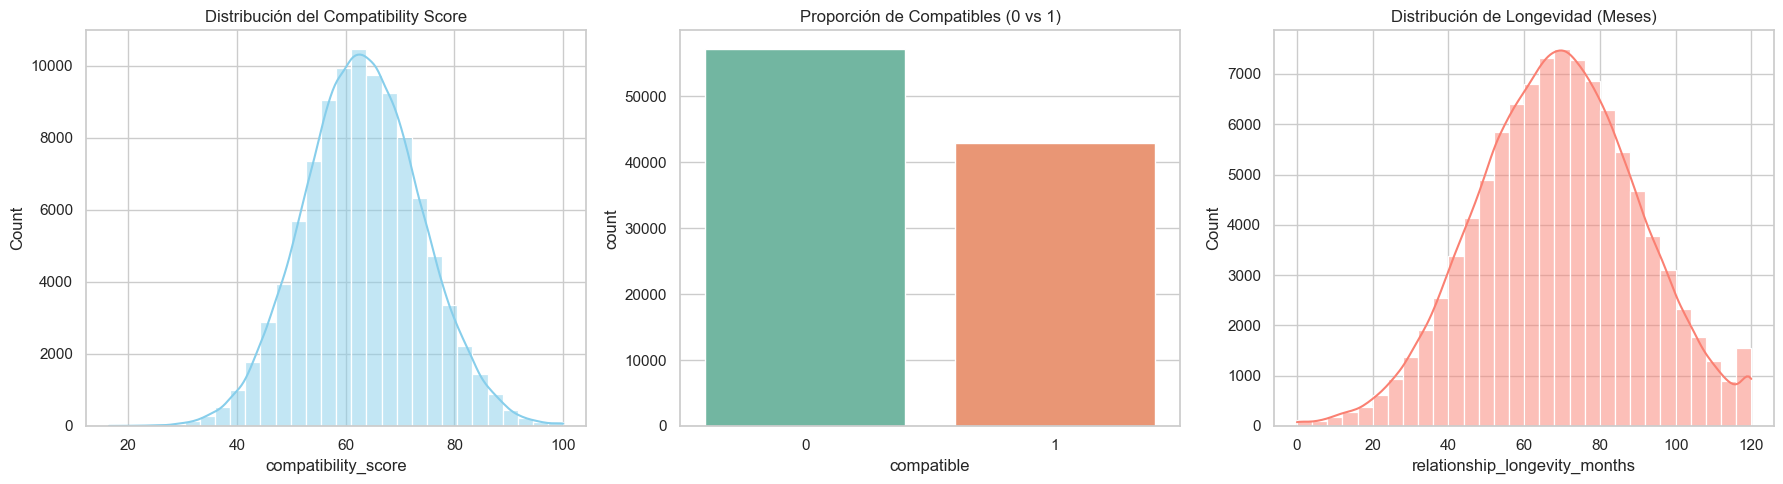

In [32]:
# 3. Análisis Univariable (Variables Objetivo)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de la puntuación de compatibilidad (Regresión)
sns.histplot(df['compatibility_score'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del Compatibility Score')

# Conteo de la etiqueta binaria de compatibilidad (Clasificación)
sns.countplot(x='compatible', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Proporción de Compatibles (0 vs 1)')

# Distribución de la longevidad de la relación en meses
sns.histplot(df['relationship_longevity_months'], bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribución de Longevidad (Meses)')

plt.tight_layout()
plt.show()


--- Correlación de las diferencias de rasgos con los objetivos ---
                               compatibility_score  compatible  \
diff_career_ambition                     -0.285153   -0.223129   
diff_emotional_expressiveness            -0.257885   -0.201426   
diff_spontaneity                         -0.173115   -0.135701   
diff_openness                            -0.130204   -0.103818   
diff_extraversion                        -0.126746   -0.097270   
diff_chronotype                          -0.121884   -0.094673   
diff_education                           -0.087471   -0.064968   
diff_conscientiousness                   -0.084398   -0.068154   
diff_agreeableness                       -0.081212   -0.063414   
diff_age                                 -0.059091   -0.044003   
relationship_longevity_months             0.549572    0.438856   
compatible                                0.794533    1.000000   
compatibility_score                       1.000000    0.794533   

       

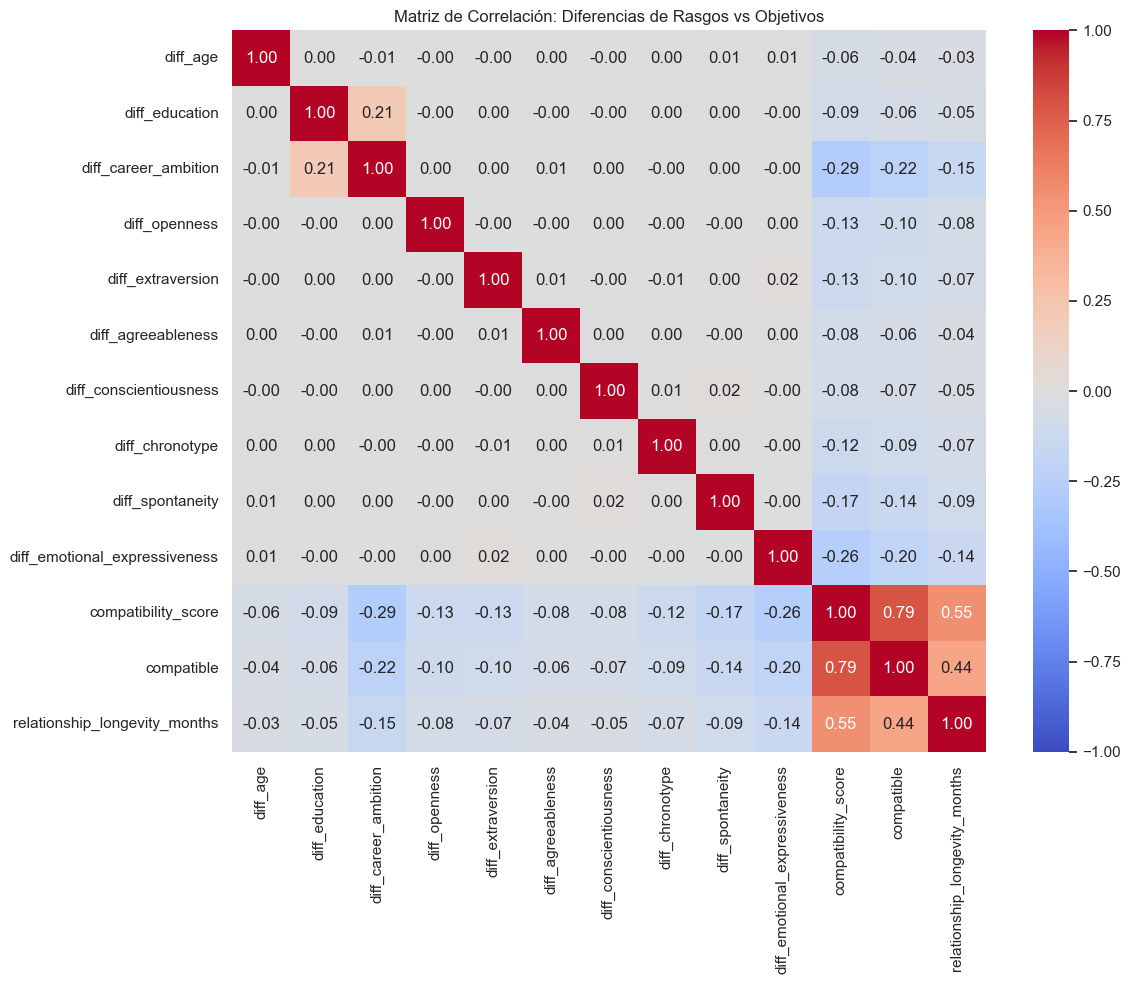

In [33]:
# 4. Análisis Bivariable y Correlaciones (Homofilia / Similitud)
# Creamos un nuevo DataFrame calculando la diferencia absoluta entre los rasgos de A y B
traits = ['age', 'education', 'career_ambition', 'openness', 'extraversion', 
          'agreeableness', 'conscientiousness', 'chronotype', 'spontaneity', 'emotional_expressiveness']

diff_df = pd.DataFrame()
for trait in traits:
    # La diferencia absoluta nos dice qué tan distintos son
    diff_df[f'diff_{trait}'] = abs(df[f'a_{trait}'] - df[f'b_{trait}'])

# Añadimos las variables objetivo
diff_df['compatibility_score'] = df['compatibility_score']
diff_df['compatible'] = df['compatible']
diff_df['relationship_longevity_months'] = df['relationship_longevity_months']

# Mostramos la correlación de estas diferencias con las variables objetivo
print("\n--- Correlación de las diferencias de rasgos con los objetivos ---")
correlations = diff_df.corr()[['compatibility_score', 'compatible', 'relationship_longevity_months']]
print(correlations.sort_values(by='compatibility_score', ascending=True))

# Graficamos la Matriz de Correlación
plt.figure(figsize=(12, 10))
corr_matrix = diff_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Diferencias de Rasgos vs Objetivos')
plt.tight_layout()
plt.show()

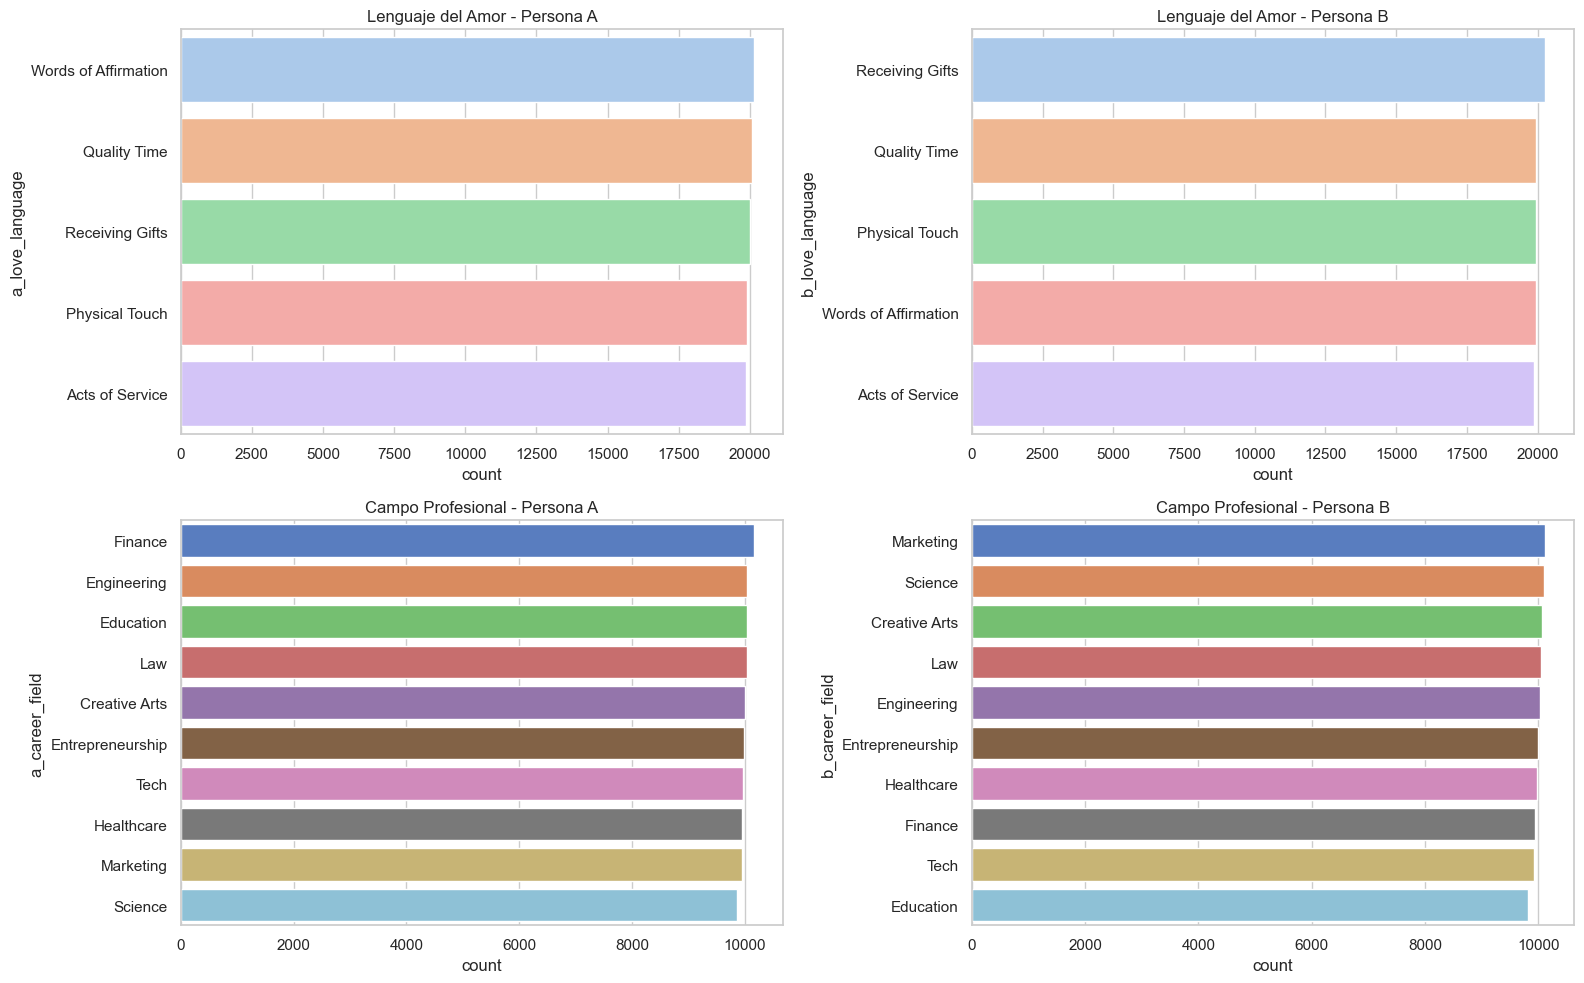

In [34]:
# 5. Análisis de Variables Categóricas (Ej. Lenguajes del Amor y Profesiones)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Lenguaje del amor Persona A
sns.countplot(y='a_love_language', data=df, ax=axes[0, 0], 
              order=df['a_love_language'].value_counts().index, palette='pastel')
axes[0, 0].set_title('Lenguaje del Amor - Persona A')

# Lenguaje del amor Persona B
sns.countplot(y='b_love_language', data=df, ax=axes[0, 1], 
              order=df['b_love_language'].value_counts().index, palette='pastel')
axes[0, 1].set_title('Lenguaje del Amor - Persona B')

# Campo profesional Persona A
sns.countplot(y='a_career_field', data=df, ax=axes[1, 0], 
              order=df['a_career_field'].value_counts().index, palette='muted')
axes[1, 0].set_title('Campo Profesional - Persona A')

# Campo profesional Persona B
sns.countplot(y='b_career_field', data=df, ax=axes[1, 1], 
              order=df['b_career_field'].value_counts().index, palette='muted')
axes[1, 1].set_title('Campo Profesional - Persona B')

plt.tight_layout()
plt.show()